# Iteration 2 — Legal-BERT et DeBERTa ameliores

**Projet Big Data & Deep Learning — Agent d'audit de conformite documentaire**

## Ce qu'on a appris a l'iteration 1

| Modele | F1 macro | Accuracy |
|---|---|---|
| TF-IDF + SVM (baseline) | **0.670** | 0.750 |
| Legal-BERT | 0.595 | **0.768** |
| BERT-base | 0.544 | 0.732 |
| DistilBERT | 0.527 | 0.724 |
| DeBERTa-v3-small | 0.479 | 0.693 |

Les Transformers sont bons sur les categories frequentes (Legal-BERT a la meilleure
accuracy) mais ratent les categories rares, ce qui fait chuter le F1 macro.
Deux causes : seulement 3 epoques, et une perte qui traite toutes les erreurs pareil.

## Ce qu'on change

1. **Ponderation des classes** : une erreur sur une categorie rare coute plus cher.
2. **Jusqu'a 10 epoques avec arret automatique** : l'entrainement s'arrete des que
   le score ne progresse plus pendant 2 epoques, et on garde la meilleure epoque.
3. **Un jeu de validation separe** (10 % du train) pour choisir la meilleure epoque.
   Le jeu de test n'est utilise qu'une fois, a la fin : c'est la methode rigoureuse.

## Mode d'emploi

1. **Execution** > **Modifier le type d'execution** > **T4 GPU** > Enregistrer
2. **Execution** > **Tout executer**
3. Cellule 3 : depose `clauses_train.jsonl` et `clauses_test.jsonl`
   (dossier `C:\projets\audit-conformite-mlops\data\processed`)

Duree : **30 a 45 minutes**.

## 1. GPU

In [1]:
import torch
if torch.cuda.is_available():
    print("GPU detecte :", torch.cuda.get_device_name(0))
else:
    print("AUCUN GPU. Execution > Modifier le type d'execution > T4 GPU, puis relance.")

GPU detecte : Tesla T4


## 2. Installation

In [2]:
!pip install -q transformers==4.46.3 accelerate==1.1.1 sentencepiece scikit-learn
print("\nInstallation terminee (les messages ERROR sur diffusers/gradio sont sans importance).")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.2/333.2 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 44.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.

Installation terminee (les messages ERROR sur diffusers/gradio sont sans importance).


## 3. Depot des donnees

Selectionne les DEUX fichiers : `clauses_train.jsonl` et `clauses_test.jsonl`.

In [3]:
from google.colab import files
import os

uploaded = files.upload()
for name in ("clauses_train.jsonl", "clauses_test.jsonl"):
    if os.path.exists(name):
        n = sum(1 for _ in open(name, encoding="utf-8"))
        print(f"OK   {name:24s} {n:>7,} lignes")
    else:
        print(f"MANQUANT : {name}  -> relance cette cellule et choisis les bons fichiers")

Saving clauses_test.jsonl to clauses_test.jsonl
Saving clauses_train.jsonl to clauses_train.jsonl
OK   clauses_train.jsonl        8,222 lignes
OK   clauses_test.jsonl         1,912 lignes


## 4. Donnees : train, validation, test

In [4]:
import json
import numpy as np
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

def load_split(path):
    texts, labels = [], []
    with open(path, encoding="utf-8") as f:
        for line in f:
            row = json.loads(line)
            if row.get("label"):
                texts.append(row["text"]); labels.append(row["label"])
    return texts, labels

X_full, y_full_raw = load_split("clauses_train.jsonl")
X_test, y_test_raw = load_split("clauses_test.jsonl")

encoder = LabelEncoder().fit(y_full_raw)
known = set(encoder.classes_)
keep = [i for i, l in enumerate(y_test_raw) if l in known]
X_test = [X_test[i] for i in keep]
y_test = encoder.transform([y_test_raw[i] for i in keep]).tolist()
y_full = encoder.transform(y_full_raw).tolist()
n_labels = len(encoder.classes_)

# Validation : 10 % du train, stratifie quand c'est possible.
counts = Counter(y_full)
strat = y_full if min(counts.values()) >= 2 else None
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.10, random_state=42, stratify=strat)

# Categories rares : moins de 100 exemples d'entrainement.
RARE = sorted(c for c, n in counts.items() if n < 100)

print(f"train      : {len(X_train):,}")
print(f"validation : {len(X_val):,}")
print(f"test       : {len(X_test):,}")
print(f"classes    : {n_labels}  (dont {len(RARE)} rares, < 100 exemples)")

train      : 7,399
validation : 823
test       : 1,912
classes    : 41  (dont 14 rares, < 100 exemples)


## 5. Poids des classes

Poids = racine de (effectif moyen / effectif de la classe). La racine adoucit
l'effet : une classe 10 fois plus rare pese environ 3 fois plus, pas 10 fois,
ce qui evite de destabiliser l'entrainement.

In [5]:
import torch

train_counts = np.bincount(y_train, minlength=n_labels).astype(float)
train_counts[train_counts == 0] = 1.0
weights = np.sqrt(train_counts.mean() / train_counts)
weights = weights / weights.mean()
CLASS_WEIGHTS = torch.tensor(weights, dtype=torch.float)

order = np.argsort(weights)
print("Poids les plus faibles (categories frequentes) :")
for i in order[:3]:
    print(f"   {encoder.classes_[i][:40]:40s} {weights[i]:.2f}")
print("Poids les plus forts (categories rares) :")
for i in order[-3:]:
    print(f"   {encoder.classes_[i][:40]:40s} {weights[i]:.2f}")

Poids les plus faibles (categories frequentes) :
   License Grant                            0.41
   Cap On Liability                         0.44
   Audit Rights                             0.44
Poids les plus forts (categories rares) :
   Unlimited/All-You-Can-Eat-License        2.01
   Price Restrictions                       2.01
   Agreement Date                           3.41


## 6. Configuration

In [6]:
MODELS = [
    {"key": "legalbert-v2", "name": "nlpaueb/legal-bert-base-uncased", "label": "Legal-BERT v2",
     "fp16": True,  "lr": 3e-5},
    {"key": "deberta-v2",   "name": "microsoft/deberta-v3-small",      "label": "DeBERTa-v3 v2",
     "fp16": False, "lr": 5e-5},
]
MAX_EPOCHS = 10
PATIENCE   = 2
BATCH_SIZE = 32
MAX_LENGTH = 256
SEED       = 42

V1 = {"TF-IDF + SVM": 0.670, "Legal-BERT v1": 0.595, "BERT-base v1": 0.544,
      "DistilBERT v1": 0.527, "DeBERTa-v3 v1": 0.479}
BASELINE_F1 = V1["TF-IDF + SVM"]
RESULTS_FILE = "benchmark_v2.json"
print(f"{len(MODELS)} modeles | jusqu'a {MAX_EPOCHS} epoques | arret apres {PATIENCE} epoques sans progres")

2 modeles | jusqu'a 10 epoques | arret apres 2 epoques sans progres


## 7. Entrainement pondere avec arret automatique

In [7]:
import gc, time, shutil
from transformers import (AutoTokenizer, AutoModelForSequenceClassification, Trainer,
                          TrainingArguments, EarlyStoppingCallback, set_seed)
from sklearn.metrics import f1_score, accuracy_score


class ClauseDataset(torch.utils.data.Dataset):
    def __init__(self, enc, labels):
        self.enc, self.labels = enc, labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, i):
        item = {k: torch.tensor(v[i]) for k, v in self.enc.items()}
        item["labels"] = torch.tensor(self.labels[i])
        return item


class WeightedTrainer(Trainer):
    """Trainer dont la perte penalise davantage les erreurs sur les classes rares."""
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss_fn = torch.nn.CrossEntropyLoss(weight=CLASS_WEIGHTS.to(outputs.logits.device))
        loss = loss_fn(outputs.logits.float(), labels)
        return (loss, outputs) if return_outputs else loss


def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=-1)
    return {"f1_macro": f1_score(p.label_ids, preds, average="macro", zero_division=0)}


def run_model(cfg):
    set_seed(SEED)
    print(f"\n{'=' * 64}\n  {cfg['label']}  ({cfg['name']})\n{'=' * 64}")
    tok = AutoTokenizer.from_pretrained(cfg["name"])
    enc = lambda X: tok(X, truncation=True, padding="max_length", max_length=MAX_LENGTH)
    ds_tr = ClauseDataset(enc(X_train), y_train)
    ds_va = ClauseDataset(enc(X_val), y_val)
    ds_te = ClauseDataset(enc(X_test), y_test)

    model = AutoModelForSequenceClassification.from_pretrained(cfg["name"], num_labels=n_labels)
    out_dir = f"ckpt_{cfg['key']}"
    args = TrainingArguments(
        output_dir=out_dir,
        num_train_epochs=MAX_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE * 2,
        learning_rate=cfg["lr"],
        warmup_ratio=0.1,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        logging_steps=50,
        fp16=cfg["fp16"],
        report_to=[],
        seed=SEED,
    )
    trainer = WeightedTrainer(
        model=model, args=args, train_dataset=ds_tr, eval_dataset=ds_va,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=PATIENCE)],
    )

    t0 = time.time()
    trainer.train()
    train_s = time.time() - t0

    evals = [h for h in trainer.state.log_history if "eval_f1_macro" in h]
    best_epoch = int(max(evals, key=lambda h: h["eval_f1_macro"])["epoch"])
    epochs_run = int(evals[-1]["epoch"])

    # Evaluation finale sur le TEST, jamais vu pendant l'entrainement.
    t0 = time.time()
    preds = np.argmax(trainer.predict(ds_te).predictions, axis=-1)
    infer_s = time.time() - t0

    rare_idx = [i for i, y in enumerate(y_test) if y in RARE]
    res = {
        "key": cfg["key"], "label": cfg["label"], "model_name": cfg["name"],
        "iteration": 2,
        "f1_macro": float(f1_score(y_test, preds, average="macro", zero_division=0)),
        "f1_weighted": float(f1_score(y_test, preds, average="weighted", zero_division=0)),
        "accuracy": float(accuracy_score(y_test, preds)),
        "f1_macro_rare": float(f1_score([y_test[i] for i in rare_idx],
                                        [preds[i] for i in rare_idx],
                                        labels=RARE, average="macro", zero_division=0)),
        "train_minutes": round(train_s / 60, 2),
        "latency_ms_per_clause": round(1000 * infer_s / len(X_test), 2),
        "params_millions": round(sum(p.numel() for p in model.parameters()) / 1e6, 1),
        "best_epoch": best_epoch, "epochs_run": epochs_run, "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE, "learning_rate": cfg["lr"], "batch_size": BATCH_SIZE,
        "max_length": MAX_LENGTH, "fp16": cfg["fp16"], "seed": SEED,
        "class_weighting": "sqrt_inverse_frequency",
        "n_train": len(X_train), "n_val": len(X_val), "n_test": len(X_test),
        "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",
    }
    np.save(f"preds_{cfg['key']}.npy", preds)
    trainer.save_model(f"model_{cfg['key']}")
    tok.save_pretrained(f"model_{cfg['key']}")
    shutil.rmtree(out_dir, ignore_errors=True)

    print(f"\n  F1 macro {res['f1_macro']:.3f} | F1 rares {res['f1_macro_rare']:.3f} | "
          f"accuracy {res['accuracy']:.3f} | meilleure epoque {best_epoch}/{epochs_run}")
    del trainer, model
    gc.collect(); torch.cuda.empty_cache()
    return res


results = json.load(open(RESULTS_FILE)) if os.path.exists(RESULTS_FILE) else []
done = {r["key"] for r in results}
for cfg in MODELS:
    if cfg["key"] in done:
        continue
    try:
        results.append(run_model(cfg))
        json.dump(results, open(RESULTS_FILE, "w"), indent=2)
    except Exception as e:
        print(f"\nECHEC sur {cfg['label']} : {type(e).__name__}: {e}")
        gc.collect(); torch.cuda.empty_cache()

print(f"\n{len(results)} / {len(MODELS)} modeles termines.")


  Legal-BERT v2  (nlpaueb/legal-bert-base-uncased)


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

/usr/local/lib/python3.13/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/286M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-small and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1 Macro
1,2.702900,2.003281,0.266226
2,1.284400,1.187903,0.505829
3,0.948900,0.960676,0.634112
4,0.747900,0.920452,0.661803
5,0.573800,0.925902,0.671887
6,0.528900,0.967472,0.662366
7,0.435500,0.992755,0.659226



  F1 macro 0.667 | F1 rares 0.541 | accuracy 0.746 | meilleure epoque 5/7

2 / 2 modeles termines.


## 8. Verdict : iteration 1 contre iteration 2

In [8]:
import pandas as pd

rows = [{"Modele": k, "Iteration": 0 if k.startswith("TF-IDF") else 1, "F1 macro": v}
        for k, v in V1.items()]
for r in results:
    rows.append({"Modele": r["label"], "Iteration": 2, "F1 macro": r["f1_macro"],
                 "F1 rares": r["f1_macro_rare"], "Accuracy": r["accuracy"],
                 "Meilleure epoque": r["best_epoch"], "Minutes": r["train_minutes"]})
table = pd.DataFrame(rows).sort_values("F1 macro", ascending=False).reset_index(drop=True)
table.to_csv("benchmark_v2_table.csv", index=False)
display(table.style.format({"F1 macro": "{:.3f}", "F1 rares": "{:.3f}",
                            "Accuracy": "{:.3f}", "Minutes": "{:.1f}"}, na_rep="—"))

best = max(results, key=lambda r: r["f1_macro"])
delta = best["f1_macro"] - BASELINE_F1
print("\n" + "=" * 64)
print(f"  Baseline TF-IDF + SVM : {BASELINE_F1:.3f}")
print(f"  Meilleur iteration 2  : {best['label']}  {best['f1_macro']:.3f}  ({delta:+.3f})")
if delta > 0:
    print("  -> La baseline est BATTUE. Ce modele devient le classifieur du projet.")
else:
    print("  -> La baseline reste devant. On la garde, et on documente pourquoi.")
print("=" * 64)

,Modele,Iteration,F1 macro,F1 rares,Accuracy,Meilleure epoque,Minutes
0,Legal-BERT v2,2,0.719,0.638,0.792,7.000000,16.7
1,TF-IDF + SVM,0,0.670,—,—,—,—
2,DeBERTa-v3 v2,2,0.667,0.541,0.746,5.000000,16.1
3,Legal-BERT v1,1,0.595,—,—,—,—
4,BERT-base v1,1,0.544,—,—,—,—
5,DistilBERT v1,1,0.527,—,—,—,—
6,DeBERTa-v3 v1,1,0.479,—,—,—,—



  Baseline TF-IDF + SVM : 0.670
  Meilleur iteration 2  : Legal-BERT v2  0.719  (+0.049)
  -> La baseline est BATTUE. Ce modele devient le classifieur du projet.


## 9. Graphique

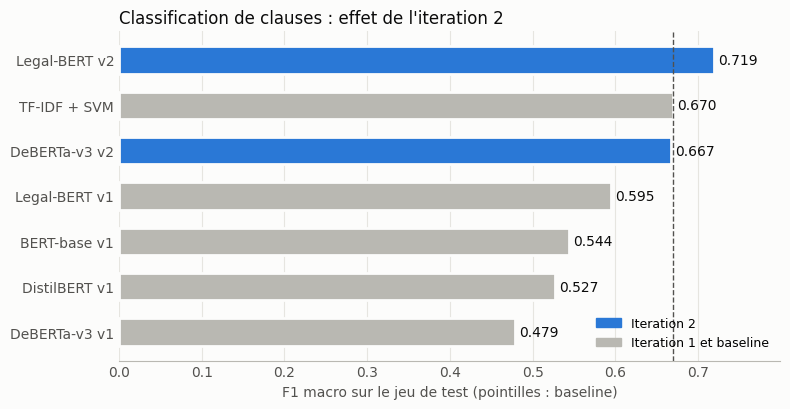

In [9]:
import matplotlib.pyplot as plt

INK, INK_2, SURFACE = "#0b0b0b", "#52514e", "#fcfcfb"
V2_COLOR, V1_COLOR, GRID = "#2a78d6", "#b9b8b2", "#e6e5e0"

plot = table.sort_values("F1 macro", ascending=True)
colors = [V2_COLOR if it == 2 else V1_COLOR for it in plot["Iteration"]]

fig, ax = plt.subplots(figsize=(8, 4.2), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
bars = ax.barh(plot["Modele"], plot["F1 macro"], color=colors, height=0.6,
               edgecolor=SURFACE, linewidth=2)
ax.axvline(BASELINE_F1, color=INK_2, linestyle="--", linewidth=1)
for bar, v in zip(bars, plot["F1 macro"]):
    ax.text(v + 0.005, bar.get_y() + bar.get_height() / 2, f"{v:.3f}",
            va="center", fontsize=10, color=INK)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=V2_COLOR, label="Iteration 2"),
                   Patch(color=V1_COLOR, label="Iteration 1 et baseline")],
          loc="lower right", frameon=False, fontsize=9)
ax.set_xlim(0, min(1.0, plot["F1 macro"].max() + 0.08))
ax.set_xlabel("F1 macro sur le jeu de test (pointilles : baseline)", color=INK_2)
ax.set_title("Classification de clauses : effet de l'iteration 2", loc="left", color=INK, fontsize=12)
ax.tick_params(colors=INK_2, length=0)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color(V1_COLOR)
ax.grid(axis="x", color=GRID, linewidth=0.8); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("benchmark_v2_f1.png", dpi=160, facecolor=SURFACE)
plt.show()

## 10. Telechargement

Le meilleur modele de l'iteration 2 est zippe avec ses etiquettes et ses metriques.

In [10]:
shutil.rmtree("best_model_v2", ignore_errors=True)
shutil.copytree(f"model_{best['key']}", "best_model_v2")
json.dump(list(encoder.classes_), open("best_model_v2/labels.json", "w"), indent=2)
json.dump(best, open("best_model_v2/metrics.json", "w"), indent=2)
!zip -qr best_model_v2.zip best_model_v2

for f in ("benchmark_v2.json", "benchmark_v2_table.csv", "benchmark_v2_f1.png", "best_model_v2.zip"):
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>